# Report walkthrough

This is the interactive counterpart to a report's `report_summary.md`. It reads an already-generated `runs/<venue>/<composite>/<run-id>/reports/<report-id>/<evaluation-id>/` directory -- written by `uv run report` -- and displays the same tables and figures interactively. It does not fit, evaluate, or write anything unless the optional regeneration cell near the end is explicitly enabled.

See [the usage guide](../../docs/technical/usage_guide.md#8-reporting), [the report configuration reference](../../docs/technical/configuration_reference.md#7-evaluation-and-report-configuration), and [the artifact reference](../../docs/technical/artifact_reference.md#composite-experiment-and-report-roots).

In [7]:
from pathlib import Path
import sys

PROJECT_ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / 'pyproject.toml').is_file())
if str(PROJECT_ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / 'src'))

REPORT_DIR = '/home/kbolat/Python/simcast/reports/lab/quick_all_methods/2026-09-22_085051'
if REPORT_DIR is None:
    candidates = sorted((PROJECT_ROOT / 'reports').rglob('report_summary.md'))
    REPORT_DIR = candidates[-1].parent if candidates else None
else:
    REPORT_DIR = Path(REPORT_DIR).expanduser()
    if not REPORT_DIR.is_absolute():
        REPORT_DIR = PROJECT_ROOT / REPORT_DIR
    if (REPORT_DIR / 'composite_manifest.json').is_file():
        run_parts = REPORT_DIR.parts
        if 'runs' not in run_parts:
            raise ValueError(f'Cannot derive report path from run directory: {REPORT_DIR}')
        run_index = run_parts.index('runs')
        REPORT_DIR = Path(*run_parts[:run_index], 'reports', *run_parts[run_index + 1:])

if REPORT_DIR is not None:
    REPORT_DIR = REPORT_DIR.resolve()
if REPORT_DIR is None or not (REPORT_DIR / 'report_summary.md').is_file():
    raise FileNotFoundError(f'Report summary not found under {REPORT_DIR}')
print(REPORT_DIR)

/home/kbolat/Python/simcast/reports/lab/quick_all_methods/2026-09-22_085051


## Report summary

Every report directory contains a generated `report_summary.md` naming its metrics, reference, and bootstrap settings, and describing every accompanying file.

In [8]:
from IPython.display import Markdown, display

if REPORT_DIR is not None:
    display(Markdown((REPORT_DIR / 'report_summary.md').read_text(encoding='utf-8')))

# Report summary

Metrics: mean_pinball.
Reference: `m0`. Bootstrap: 200 replicates, block lengths [7, 3].

| File | Contents |
|---|---|
| `method_comparison_mean_pinball.pdf` | bar chart of `mean_pinball` per experiment/method (pdf) |
| `method_comparison_mean_pinball.png` | bar chart of `mean_pinball` per experiment/method (png) |
| `method_summary.csv` | mean value per (base, experiment, method, seed), one row per metric |
| `paired_effects.csv` | moving-block bootstrap paired contrasts vs. the reference, one row per metric/comparison |
| `per_origin_metrics.parquet` | concatenated per-origin, per-method evaluation records; input to every file below |


## Method summary and paired effects

`method_summary.csv` is the mean value of each configured metric per base, experiment, method, and seed. `paired_effects.csv` is the moving-block bootstrap contrast of each method against the declared reference, one row per metric, comparison, and block length. Both are read here exactly as written; nothing is recomputed.

In [9]:
import pandas as pd

if REPORT_DIR is not None:
    method_summary = pd.read_csv(REPORT_DIR / 'method_summary.csv')
    paired_effects = pd.read_csv(REPORT_DIR / 'paired_effects.csv')
    display(method_summary)
    display(paired_effects)

,metric,base_id,experiment_id,method,configured_seed,value
0,mean_pinball,transformer,m0,independent,deterministic,3764729.2
1,mean_pinball,transformer,m1,independent,deterministic,3764729.2
2,mean_pinball,transformer,m1,static_gaussian,deterministic,3761604.0
3,mean_pinball,transformer,m2,conditional_low_rank,42,3712414.8
4,mean_pinball,transformer,m2,independent,42,3764729.2
5,mean_pinball,transformer,m3,independent,42,3764729.2
6,mean_pinball,transformer,m3,set_aware_low_rank,42,3737062.2
7,mean_pinball,transformer,m4,conditional_kernel,42,4089186.2
8,mean_pinball,transformer,m4,independent,42,3764729.2


,metric,base_id,experiment_id,method,reference,mean_difference,percentage_difference,ci_lower,ci_upper,percentage_ci_lower,percentage_ci_upper,block_length,bootstrap_replicates,number_of_origins
0,mean_pinball,transformer,m1,static_gaussian,independent,-3125.537500,-0.083022,-14048.152143,3525.935670,-0.373152,0.093657,7,200,70
1,mean_pinball,transformer,m1,static_gaussian,independent,-3125.537500,-0.083022,-13715.172723,4220.708348,-0.364307,0.112112,3,200,70
2,mean_pinball,transformer,m2,conditional_low_rank,independent,-52314.585714,-1.389597,-97066.046786,-28617.179821,-2.578301,-0.760139,7,200,70
3,mean_pinball,transformer,m2,conditional_low_rank,independent,-52314.585714,-1.389597,-95556.331071,-24922.095937,-2.538199,-0.661989,3,200,70
4,mean_pinball,transformer,m3,set_aware_low_rank,independent,-27667.185714,-0.734905,-63608.875580,1069.161830,-1.689600,0.028399,7,200,70
5,mean_pinball,transformer,m3,set_aware_low_rank,independent,-27667.185714,-0.734905,-56977.402366,6789.648750,-1.513453,0.180349,3,200,70
6,mean_pinball,transformer,m4,conditional_kernel,independent,324456.980357,8.618335,238792.657768,430195.288170,6.342890,11.426991,7,200,70
7,mean_pinball,transformer,m4,conditional_kernel,independent,324456.980357,8.618335,220222.125714,418699.821429,5.849614,11.121644,3,200,70


## Method comparison figures

Each configured metric has a `method_comparison_<metric>.png` vertically stacked base-panel absolute-score chart and a `paired_effect_<metric>.png` vertically stacked chart showing relative improvement over the reference. The paired chart includes one marker and bootstrap interval for every configured block length; positive values favor the tested method. They are shown inline here exactly as saved; nothing is replotted.

method_comparison_mean_pinball.png


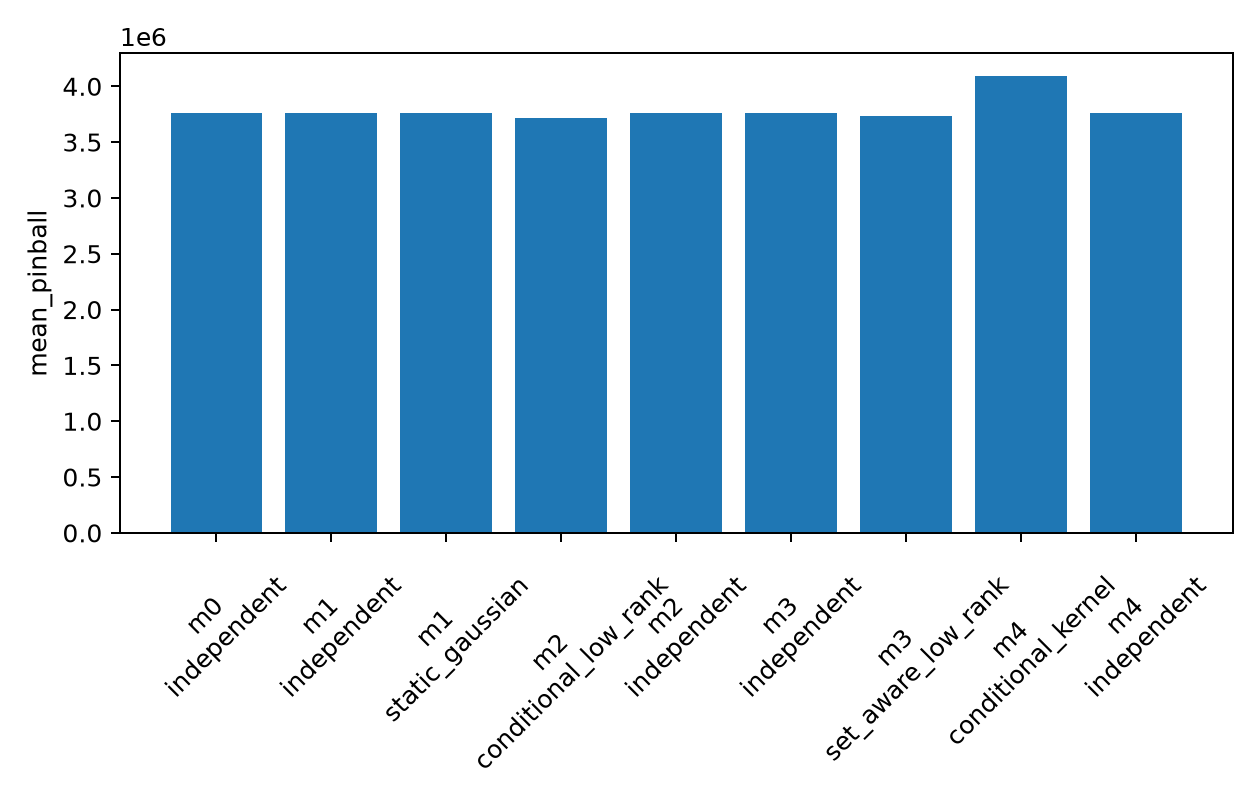

In [10]:
from IPython.display import Image

if REPORT_DIR is not None:
    for path in sorted(REPORT_DIR.glob('method_comparison_*.png')):
        print(path.name)
        display(Image(filename=str(path)))

## Regenerating this report with different metrics or analyses

`uv run report` reads only the recorded evaluations listed in the run's `composite_manifest.json`; it never calls Chronos, a dependence fitter, or the evaluator. This makes it safe to rerun repeatedly while iterating on which metrics, bootstrap settings, or figures to produce. Disabled by default so opening this notebook never writes anything.

In [11]:
from simcast.cli.report_composite import report_composite

REGENERATE = False  # set True to actually write a new report directory
REPORT_CONFIG = 'configs/reports/powertech2027_main.yaml'
if REGENERATE:
    new_report_dir = report_composite(PROJECT_ROOT / REPORT_CONFIG)
    print(new_report_dir)

## Configuration and implementation map

`reference`, `metrics`, and `analysis` in a `report` YAML document (Section 7.2 of the [configuration reference](../../docs/technical/configuration_reference.md#7-evaluation-and-report-configuration)) control what this notebook displays. `simcast.reporting.composite_report.write_composite_report` builds every file above; `simcast.cli.report_composite.report_composite` (the `uv run report` command) is used in the regeneration cell. The [artifact reference](../../docs/technical/artifact_reference.md#composite-experiment-and-report-roots) defines the exact schema of each file.